In [122]:
import pandas as pd
import numpy as np
import tsfresh

In [149]:
data = pd.read_parquet("../albania_res.parquet")
data.index = pd.to_datetime(data.index, utc="UTC")

In [124]:
#data.reset_index(drop=False,inplace=True)

In [150]:
data.shape

(70127, 26)

#### using timestamp as id column as each row represents different observations

In [182]:
df = data[(data.index>='2016-01-01 00:30:00+00:00')&(data.index<'2016-01-02 00:30:00+00:00')]
df = df[['Temperature', 'Humidity', 'NetLoad']]

In [183]:
y = df[['NetLoad']]

In [185]:
df.pop('NetLoad')

,Temperature,Humidity
timestamp,,
2016-01-01 00:30:00+00:00,-0.400000,64.000000
2016-01-01 01:00:00+00:00,-0.400000,64.000000
2016-01-01 01:30:00+00:00,-0.733333,65.333333
2016-01-01 02:00:00+00:00,-0.733333,65.333333
2016-01-01 02:30:00+00:00,-1.066667,66.666667
2016-01-01 03:00:00+00:00,-1.066667,66.666667
2016-01-01 03:30:00+00:00,-1.400000,68.000000
2016-01-01 04:00:00+00:00,-1.400000,68.000000
2016-01-01 04:30:00+00:00,-1.666667,60.333333


In [186]:
df = df.reset_index()
df_features = tsfresh.extract_features(df, column_id='timestamp', column_sort='timestamp')
df_features.columns
'''
df = df[['index', 'timestamp', 'Temperature', 'Humidity','NetLoad']]
y = df.pop('NetLoad')
df_features = tsfresh.extract_features(df, column_id='index', column_sort='timestamp')
df_feature.columns
'''

Feature Extraction: 100%|██████████| 20/20 [00:02<00:00,  8.38it/s]


"\ndf = df[['index', 'timestamp', 'Temperature', 'Humidity','NetLoad']]\ny = df.pop('NetLoad')\ndf_features = tsfresh.extract_features(df, column_id='index', column_sort='timestamp')\ndf_feature.columns\n"

In [187]:
df_features.shape

(48, 1566)

In [188]:
import tsfresh.feature_extraction.settings
kind_to_fc_parameterts_all = tsfresh.feature_extraction.settings.from_columns(df_features)

In [191]:
from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute

impute(df_features)
features_filtered = select_features(df_features, y.NetLoad)

/Users/shridhar/Documents/GitHub/mlpforecast/venv/lib/python3.11/site-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['Temperature__mean_abs_change' 'Temperature__mean_change'
 'Temperature__mean_second_derivative_central' ...
 'Humidity__permutation_entropy__dimension_7__tau_1'
 'Humidity__query_similarity_count__query_None__threshold_0.0'
 'Humidity__mean_n_absolute_max__number_of_maxima_7'] did not have any finite values. Filling with zeros.
  warnings.warn(


In [192]:
features_filtered.shape

(48, 52)

### Combining all above to extract only relavant features

In [194]:
df.columns
y.columns

Index(['NetLoad'], dtype='object')

In [196]:
from tsfresh import extract_relevant_features
from tsfresh.feature_extraction import ComprehensiveFCParameters
extraction_settings  = ComprehensiveFCParameters()
features_filtered_direct = extract_relevant_features(df, y.NetLoad,
                                                     column_id='timestamp', column_sort='timestamp',default_fc_parameters=extraction_settings)

Feature Extraction: 100%|██████████| 20/20 [00:02<00:00,  7.62it/s]


In [197]:
features_filtered_direct.shape

(48, 52)

# check for multi-correlation

<Axes: >

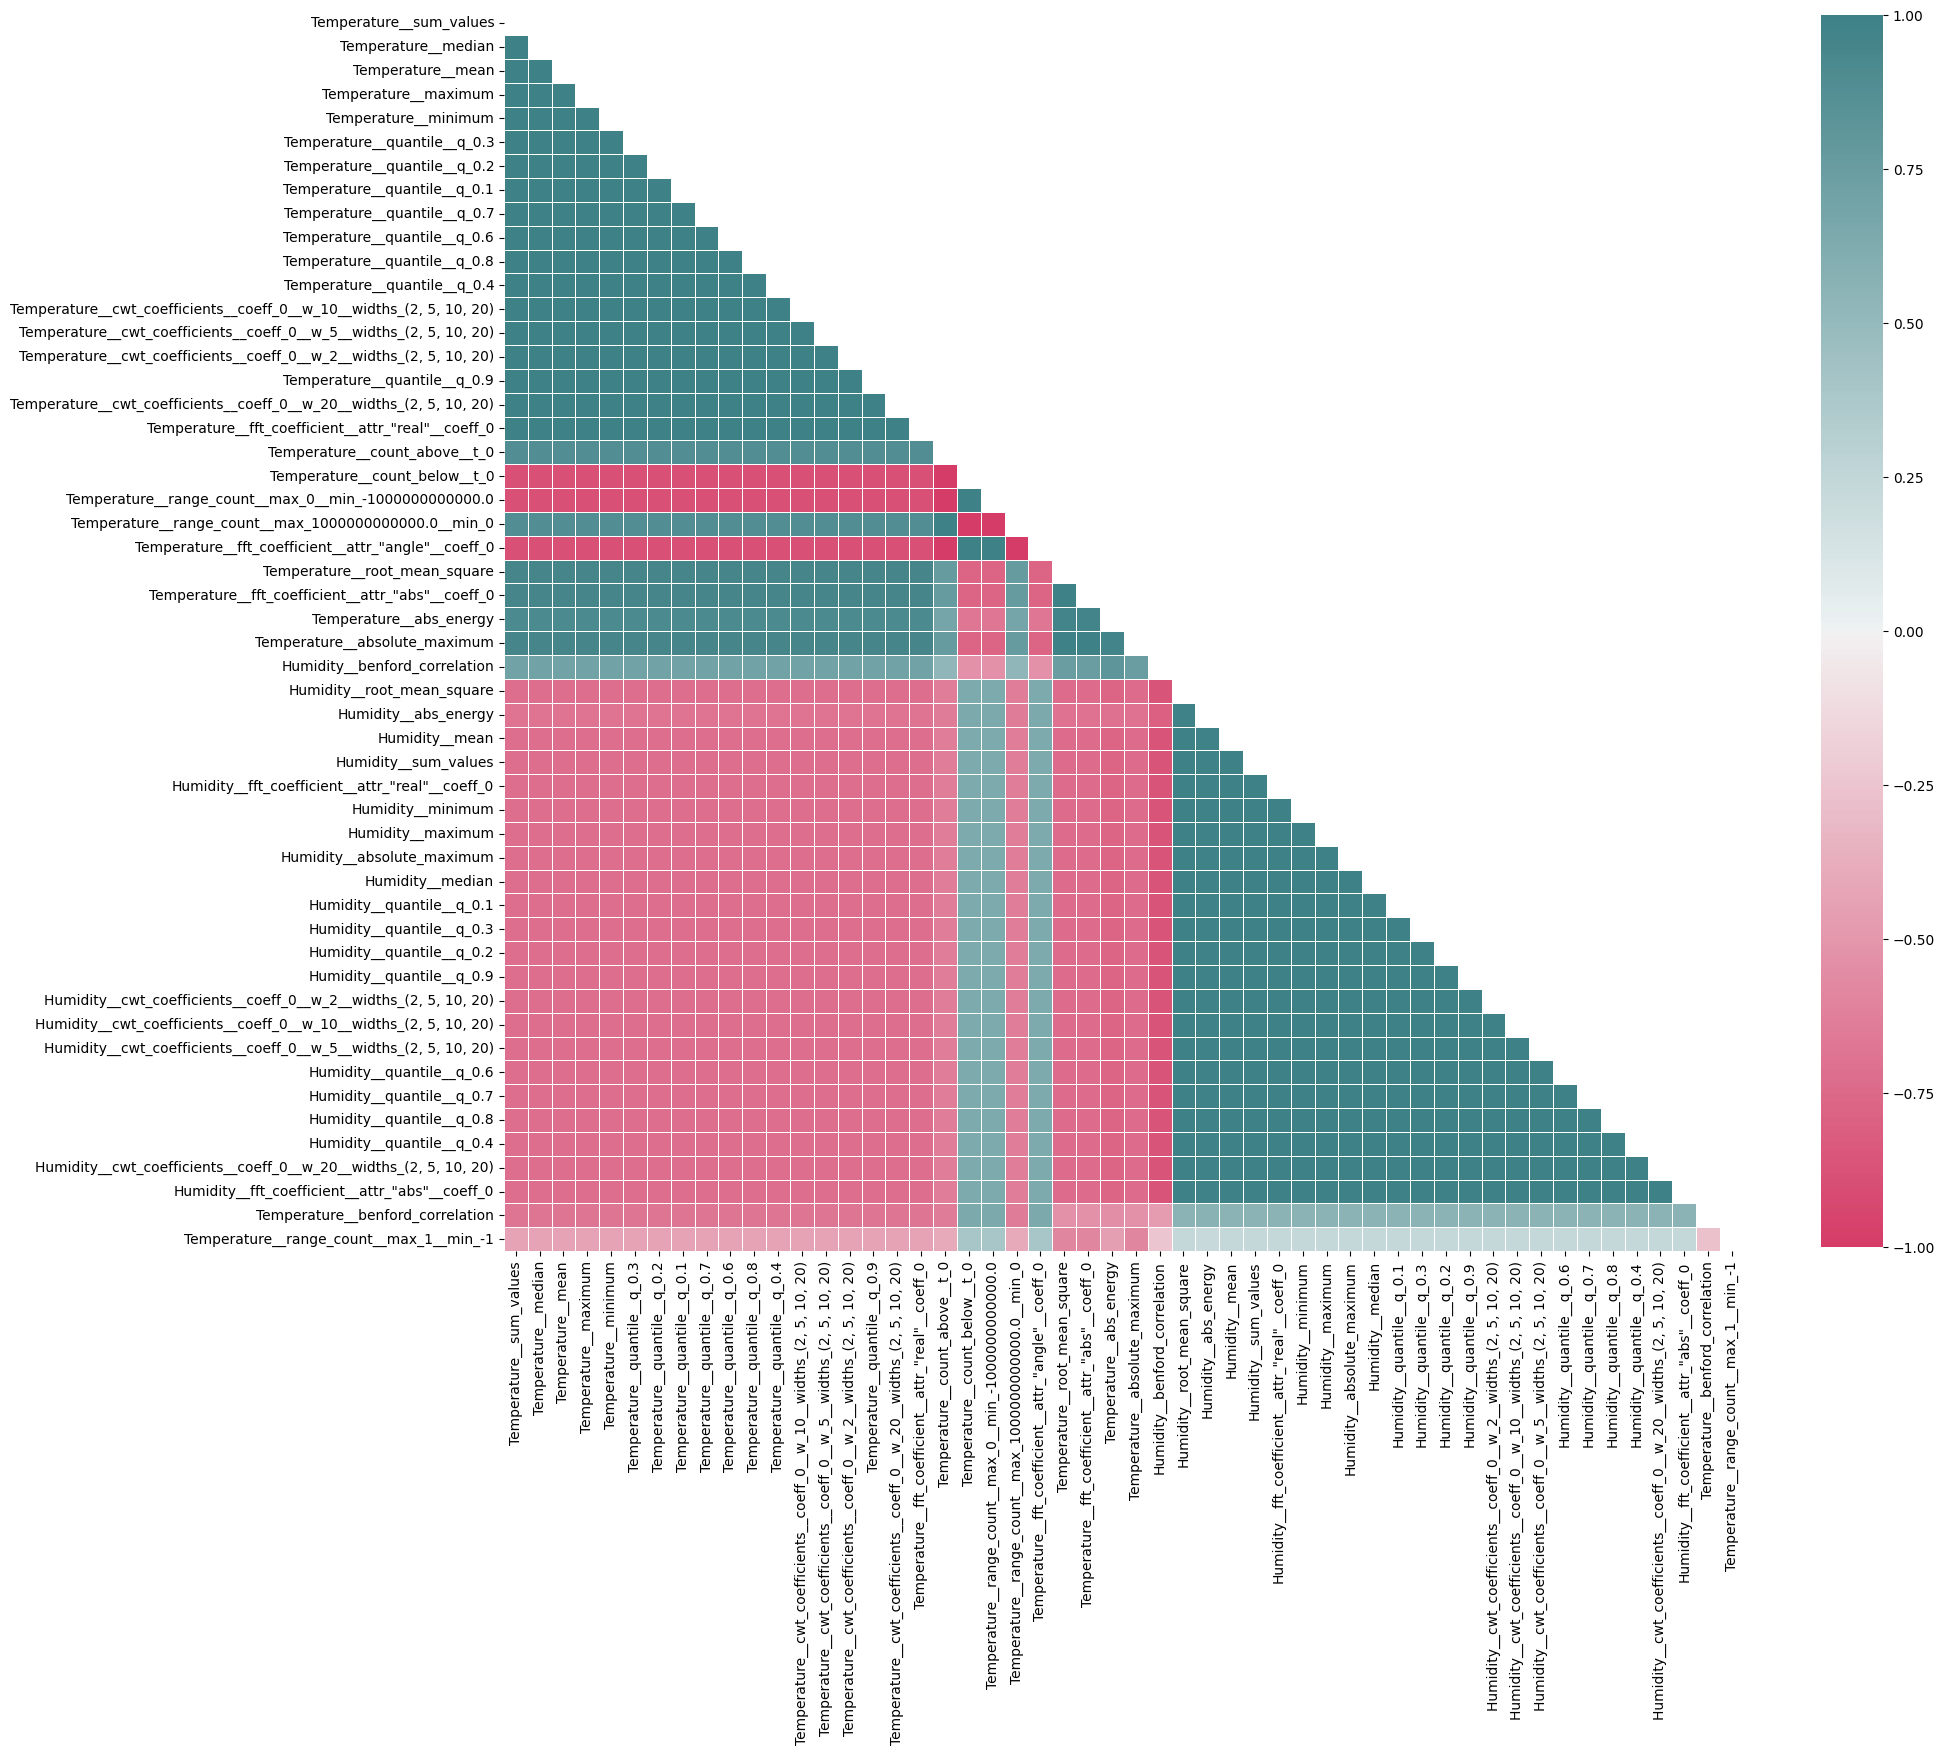

In [218]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
corr = features_filtered_direct.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(20, 20))
cmap = sns.diverging_palette(1, 200, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, annot=False, linewidths=.5, cbar_kws={"shrink": 0.8})

In [219]:
# Spot the categorical feature pairs with high correlation
threshold = 0.9999
high_corrs = (corr[abs(corr) > threshold][corr != 1.0]).unstack().dropna().to_dict()
unique_high_corrs = pd.DataFrame(list(set([(tuple(sorted(key)), high_corrs[key]) for key in high_corrs])), columns=['feature_pair', 'correlation_coefficient'])
unique_high_corrs = unique_high_corrs.loc[abs(unique_high_corrs['correlation_coefficient']).argsort()[::-1]]
pd.options.display.max_colwidth = 200
unique_high_corrs

,feature_pair,correlation_coefficient
2,"(Temperature__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20), Temperature__fft_coefficient__attr_""real""__coeff_0)",1.0
16,"(Temperature__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20), Temperature__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20))",1.0
89,"(Temperature__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20), Temperature__quantile__q_0.1)",1.0
82,"(Temperature__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20), Temperature__quantile__q_0.8)",1.0
64,"(Temperature__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20), Temperature__mean)",1.0
...,...,...
75,"(Temperature__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20), Temperature__quantile__q_0.3)",1.0
24,"(Temperature__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20), Temperature__quantile__q_0.6)",1.0
23,"(Temperature__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20), Temperature__mean)",1.0
13,"(Temperature__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20), Temperature__quantile__q_0.8)",1.0


### Feature importance

In [208]:
from sklearn.ensemble import RandomForestRegressor

In [209]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [210]:
model.fit(features_filtered_direct, y.NetLoad)

RandomForestRegressor(random_state=42)

In [211]:
importances = model.feature_importances_

In [212]:
feature_importance_df = pd.DataFrame({
    'Feature': features_filtered_direct.columns,
    'Importance': importances
})

In [213]:
feature_importance_df

,Feature,Importance
0,Temperature__sum_values,0.060813
1,Temperature__median,0.074860
2,Temperature__mean,0.045559
3,Temperature__maximum,0.018795
4,Temperature__minimum,0.043307
5,Temperature__quantile__q_0.3,0.041899
6,Temperature__quantile__q_0.2,0.089021
7,Temperature__quantile__q_0.1,0.054491
8,Temperature__quantile__q_0.7,0.021352
9,Temperature__quantile__q_0.6,0.036560


In [214]:
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

                                              Feature  Importance
6                        Temperature__quantile__q_0.2    0.089021
17  Temperature__fft_coefficient__attr_"real"__coe...    0.077253
1                                 Temperature__median    0.074860
0                             Temperature__sum_values    0.060813
7                        Temperature__quantile__q_0.1    0.054491
14  Temperature__cwt_coefficients__coeff_0__w_2__w...    0.051205
12  Temperature__cwt_coefficients__coeff_0__w_10__...    0.048973
2                                   Temperature__mean    0.045559
15                       Temperature__quantile__q_0.9    0.045108
4                                Temperature__minimum    0.043307
5                        Temperature__quantile__q_0.3    0.041899
13  Temperature__cwt_coefficients__coeff_0__w_5__w...    0.040362
9                        Temperature__quantile__q_0.6    0.036560
19                      Temperature__count_below__t_0    0.030424
11        

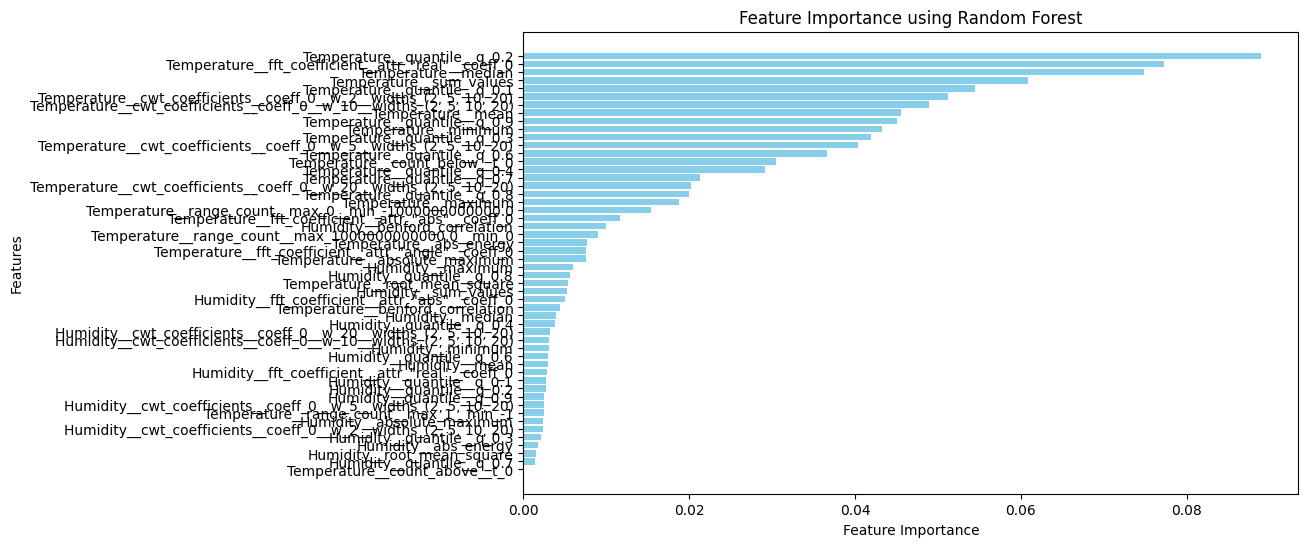

In [216]:
import matplotlib.pyplot as plt
# Display feature importance
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance using Random Forest')
plt.gca().invert_yaxis()  # To display the most important feature at the top
plt.show()

# Creating Rolling Window

In [81]:
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import roll_time_series
from tsfresh.utilities.dataframe_functions import impute

In [117]:
 df = data[['timestamp', 'Temperature', 'Humidity', 'NetLoad']]

In [118]:
df.reset_index(drop=False,inplace=True)

In [119]:
df.columns

Index(['index', 'timestamp', 'Temperature', 'Humidity', 'NetLoad'], dtype='object')

In [120]:
df

,index,timestamp,Temperature,Humidity,NetLoad
0,0,2016-01-01 00:30:00+00:00,-0.400000,64.000000,971.727939
1,1,2016-01-01 01:00:00+00:00,-0.400000,64.000000,971.727939
2,2,2016-01-01 01:30:00+00:00,-0.733333,65.333333,822.149390
3,3,2016-01-01 02:00:00+00:00,-0.733333,65.333333,822.149390
4,4,2016-01-01 02:30:00+00:00,-1.066667,66.666667,697.751976
...,...,...,...,...,...
70122,70122,2019-12-31 21:30:00+00:00,4.400000,66.000000,1120.765704
70123,70123,2019-12-31 22:00:00+00:00,4.400000,66.000000,1120.765704
70124,70124,2019-12-31 22:30:00+00:00,4.266667,67.666667,1048.766506
70125,70125,2019-12-31 23:00:00+00:00,4.266667,67.666667,1048.766506


In [121]:
df_rolled = roll_time_series(df, column_id="index", column_sort="timestamp",
                             max_timeshift=48, min_timeshift=24)

Rolling: 100%|██████████| 1/1 [00:04<00:00,  4.55s/it]


KeyError: 'id'

In [108]:
df_rolled.tail(200)

,index,timestamp,Temperature,Humidity,NetLoad,Session,id
1859638,70109,2019-12-31 15:00:00+00:00,10.866667,34.000000,1260.564134,1,"(1, 2019-12-31 16:30:00+00:00)"
1859639,70110,2019-12-31 15:30:00+00:00,11.800000,37.000000,1312.138720,1,"(1, 2019-12-31 16:30:00+00:00)"
1859640,70111,2019-12-31 16:00:00+00:00,11.800000,37.000000,1312.138720,1,"(1, 2019-12-31 16:30:00+00:00)"
1859641,70112,2019-12-31 16:30:00+00:00,9.466667,45.000000,1405.220570,1,"(1, 2019-12-31 16:30:00+00:00)"
1859642,70043,2019-12-30 06:00:00+00:00,0.733333,68.666667,624.779656,1,"(1, 2019-12-31 17:00:00+00:00)"
...,...,...,...,...,...,...,...
1859833,70112,2019-12-31 16:30:00+00:00,9.466667,45.000000,1405.220570,1,"(1, 2019-12-31 18:30:00+00:00)"
1859834,70113,2019-12-31 17:00:00+00:00,9.466667,45.000000,1405.220570,1,"(1, 2019-12-31 18:30:00+00:00)"
1859835,70114,2019-12-31 17:30:00+00:00,7.133333,53.000000,1498.215812,1,"(1, 2019-12-31 18:30:00+00:00)"
1859836,70115,2019-12-31 18:00:00+00:00,7.133333,53.000000,1498.215812,1,"(1, 2019-12-31 18:30:00+00:00)"
